# 03. Model Evaluation: Evaluación del Modelo para la Predicción de is_recommended

## Introducción y Objetivos

En un flujo de **Machine Learning** orientado a problemas de clasificación binaria, la etapa de evaluación final constituye una fase fundamental del proceso analítico, ya que permite estimar el desempeño real del modelo sobre datos que no fueron utilizados durante el entrenamiento ni durante la selección de hiperparámetros.

El propósito de esta etapa no es demostrar que el modelo funciona correctamente sobre los datos que ya conoce, sino medir su capacidad de generalización frente a observaciones nuevas, simulando un escenario similar al que enfrentaría en un entorno de producción.

Este notebook corresponde a la tercera etapa del proyecto (**03_model_evaluation.ipynb**) y tiene como objetivo evaluar el modelo seleccionado durante la fase de modelado supervisado utilizando exclusivamente el conjunto de prueba (*test set*), el cual permaneció completamente aislado durante las etapas de entrenamiento, validación cruzada y optimización de hiperparámetros.

### Objetivos específicos

Los objetivos específicos de este notebook son:

- Cargar el mejor modelo previamente entrenado y almacenado en `models/best_model.pkl`.
- Cargar el conjunto de prueba:
  - `data/processed/X_test_processed.pkl`
  - `data/processed/y_test.pkl`
- Generar predicciones sobre datos no observados previamente por el modelo.
- Evaluar el desempeño mediante métricas de clasificación:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
  - **Classification Report**
  - **Matriz de Confusión**
  - **Curva ROC**
  - **Área bajo la curva (ROC-AUC)**
- Analizar e interpretar los resultados obtenidos desde una perspectiva estadística y de negocio.
- Evaluar la capacidad de generalización del modelo comparando los resultados obtenidos en el conjunto de prueba con los observados durante la validación cruzada.
- Analizar la importancia de variables cuando la naturaleza del modelo lo permita, aportando elementos de interpretabilidad al proceso predictivo.

### Restricción metodológica

Como principio fundamental de evaluación, el conjunto de entrenamiento **no será utilizado en ninguna métrica reportada en este notebook**. Todas las evaluaciones presentadas se calcularán exclusivamente sobre el conjunto de prueba, garantizando así una estimación objetiva e imparcial del desempeño esperado del modelo en un escenario real de aplicación.

In [1]:
# =========================
# Configuración e Imports
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Carga de Artefactos (Modelo y Datos de Test)

Para realizar la evaluación final del modelo es necesario cargar los artefactos generados en las etapas anteriores del proyecto.

Los elementos requeridos son:

- **Modelo entrenado:** `models/best_model.pkl`
- **Características procesadas del conjunto de prueba:** `data/processed/X_test_processed.pkl`
- **Etiquetas reales del conjunto de prueba:** `data/processed/y_test.pkl`

### Verificación de consistencia

Antes de generar predicciones es fundamental comprobar que:

- La cantidad de registros en `X_test` coincide con la cantidad de etiquetas en `y_test`.
- Los archivos fueron cargados correctamente.
- No existen problemas de alineación entre observaciones y etiquetas.

Esta validación evita errores que podrían comprometer la confiabilidad de las métricas calculadas posteriormente.

In [2]:
# =========================
# Carga de Artefactos
# =========================

from pathlib import Path

# Rutas basadas en la estructura del proyecto
BASE_DIR = Path.cwd().parent  # sube desde /notebooks a la raíz del proyecto

models_dir = BASE_DIR / "models"
data_dir = BASE_DIR / "data" / "processed"

best_model_path = models_dir / "best_model.pkl"
X_test_path = data_dir / "X_test_processed.pkl"
y_test_path = data_dir / "y_test.pkl"

# --- Carga del modelo ---
best_model = joblib.load(best_model_path)

# --- Carga de datos ---
X_test = joblib.load(X_test_path)
y_test = joblib.load(y_test_path)

print(f"Modelo cargado desde: {best_model_path}")
print(f"Tipo de X_test: {type(X_test)}")
print(f"Tipo de y_test: {type(y_test)}")

# Conversión mínima para chequeo de dimensiones (sin evaluar en train)
y_test_arr = np.asarray(y_test)

print("\n--- Dimensiones ---")
print("X_test shape:", getattr(X_test, "shape", None))
print("y_test shape:", y_test_arr.shape)

# Chequeo básico de consistencia (mismo número de filas)
n_X = X_test.shape[0] if hasattr(X_test, "shape") else len(X_test)
n_y = y_test_arr.shape[0]
print("¿número de filas coincide?:", n_X == n_y)


Modelo cargado desde: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\best_model.pkl
Tipo de X_test: <class 'numpy.ndarray'>
Tipo de y_test: <class 'pandas.Series'>

--- Dimensiones ---
X_test shape: (185285, 385)
y_test shape: (185285,)
¿número de filas coincide?: True


## Carga de Múltiples Modelos para Evaluación Comparativa

Además del mejor modelo ya identificado, se cargan los demás modelos entrenados para realizar una **evaluación comparativa rigurosa**.

Comparar múltiples modelos sobre el mismo conjunto de test permite:
- Cuantificar cuánto mejora un modelo complejo respecto al baseline lineal.
- Detectar overfitting si el modelo más complejo no generaliza mejor.
- Justificar técnicamente la elección del modelo final con evidencia empírica.


In [3]:
# =============================================================
# Carga de todos los modelos entrenados
# =============================================================

trained_models_dir = BASE_DIR / "models" / "trained_models"

model_paths = {
    "Logistic Regression": trained_models_dir / "logistic_regression.pkl",
    "Random Forest"      : trained_models_dir / "random_forest.pkl",
    "Gradient Boosting"  : trained_models_dir / "gradient_boosting.pkl",
}

models = {}
for name, path in model_paths.items():
    if path.exists():
        models[name] = joblib.load(path)
        print(f"[OK] {name} cargado desde {path.name}")
    else:
        print(f"[WARN] No se encontró el modelo: {path}")

# Si best_model no está en el dict, lo agregamos como fallback
if not models:
    print("[INFO] Usando best_model como único modelo disponible.")
    models["Best Model"] = best_model


[WARN] No se encontró el modelo: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\trained_models\logistic_regression.pkl
[WARN] No se encontró el modelo: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\trained_models\random_forest.pkl
[WARN] No se encontró el modelo: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\trained_models\gradient_boosting.pkl
[INFO] Usando best_model como único modelo disponible.


## Evaluación Comparativa: Métricas por Modelo

Se calculan las mismas métricas para todos los modelos sobre el conjunto de test, asegurando una comparación justa bajo idénticas condiciones.

### Métricas evaluadas
- **Accuracy**: proporción total de predicciones correctas.
- **Precision**: de los predichos positivos, cuántos realmente lo son.
- **Recall**: de los positivos reales, cuántos fueron detectados.
- **F1-Score**: media armónica entre precision y recall; útil con clases desbalanceadas.
- **ROC-AUC**: capacidad discriminatoria general del modelo, independiente del umbral.


In [5]:
# =============================================================
# Cálculo de métricas comparativas
# =============================================================

from sklearn.metrics import roc_auc_score

comparison_rows = []

for model_name, model in models.items():
    y_p = model.predict(X_test)

    acc  = accuracy_score(y_test, y_p)
    prec = precision_score(y_test, y_p, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_p, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_p, average="weighted", zero_division=0)

    roc = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        try:
            if proba.shape[1] == 2:
                roc = roc_auc_score(y_test, proba[:, 1])
            else:
                roc = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")
        except Exception:
            roc = None

    comparison_rows.append({
        "Modelo"   : model_name,
        "Accuracy" : round(acc,  4),
        "Precision": round(prec, 4),
        "Recall"   : round(rec,  4),
        "F1-Score" : round(f1,   4),
        "ROC-AUC"  : round(roc,  4) if roc is not None else "N/A",
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Modelo")
print("\n===== Tabla Comparativa de Modelos =====")
print(comparison_df.to_string())



===== Tabla Comparativa de Modelos =====
            Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                    
Best Model     0.964     0.9672   0.964    0.9649    0.987


## Visualización Comparativa de Métricas

Los gráficos permiten identificar visualmente las diferencias entre modelos y los trade-offs relevantes.


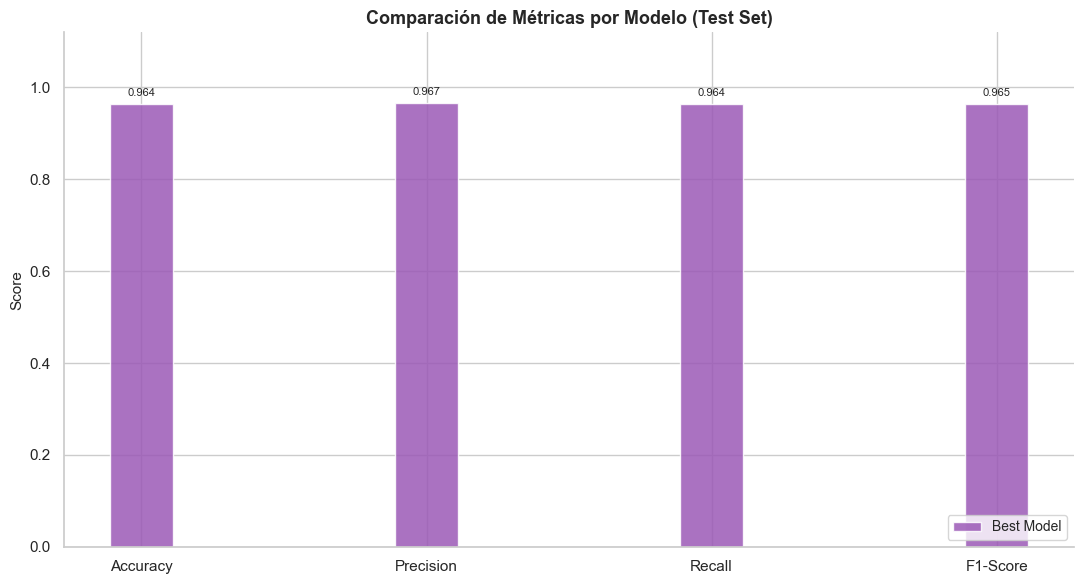

In [6]:
# =============================================================
# Gráfico de barras comparativo
# =============================================================

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Filtramos solo columnas numéricas para el gráfico
plot_df = comparison_df[metrics_to_plot].copy()

x      = np.arange(len(metrics_to_plot))
n_models = len(plot_df)
width  = 0.22
colors = ["#9b59b6", "#d81b60", "#f39c12"]  # morado, rosa, naranja

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model_name, row) in enumerate(plot_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(
        x + offset,
        row.values.astype(float),
        width,
        label=model_name,
        color=colors[i % len(colors)],
        alpha=0.85,
        edgecolor="white",
    )
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparación de Métricas por Modelo (Test Set)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


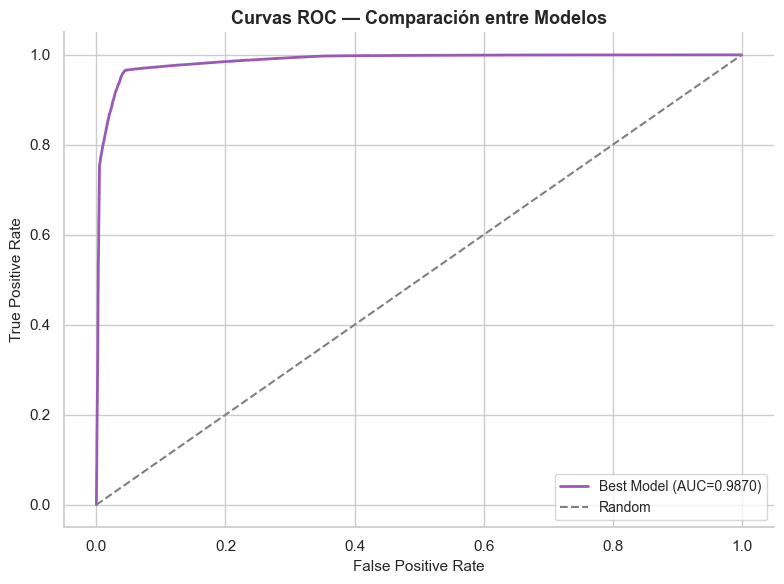

In [7]:
# =============================================================
# Curvas ROC superpuestas por modelo
# =============================================================

from sklearn.metrics import roc_curve as sk_roc_curve

roc_colors = ["#9b59b6", "#d81b60", "#f39c12"]
y_true_arr = np.asarray(y_test)

fig, ax = plt.subplots(figsize=(8, 6))

for (model_name, model), color in zip(models.items(), roc_colors):
    if not hasattr(model, "predict_proba"):
        continue
    proba = model.predict_proba(X_test)
    # Clase positiva: índice 1 (binario)
    classes = getattr(model, "classes_", [0, 1])
    pos_idx = list(classes).index(1) if 1 in classes else -1
    scores  = proba[:, pos_idx]
    try:
        fpr, tpr, _ = sk_roc_curve(y_true_arr, scores)
        roc_val = roc_auc_score(y_true_arr, scores)
        ax.plot(fpr, tpr, lw=2, color=color, label=f"{model_name} (AUC={roc_val:.4f})")
    except Exception as e:
        print(f"[WARN] No se pudo trazar ROC para {model_name}: {e}")

ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Curvas ROC — Comparación entre Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


### Interpretación de la Comparación entre Modelos

La tabla y los gráficos anteriores permiten extraer conclusiones sobre el trade-off entre complejidad y rendimiento:

- **Logistic Regression (baseline)**: modelo lineal, rápido e interpretable. Sus coeficientes permiten analizar directamente el efecto de cada variable. Si el resto de modelos no lo supera significativamente, indica que el problema tiene estructura esencialmente lineal.
- **Random Forest**: ensamble de árboles por bagging. Captura relaciones no lineales y ofrece importancia de variables nativa. Comparado con el baseline, un salto importante en F1 justifica la complejidad adicional.
- **Gradient Boosting**: ensamble secuencial. Generalmente el modelo más preciso en clasificación tabular, a costa de mayor tiempo de entrenamiento. La diferencia de AUC respecto a RF cuantifica si el boosting aporta valor real.

> **Conclusión clave**: el modelo elegido como final debe ser aquel que maximiza F1-Score y ROC-AUC en el test set, considerando también el costo computacional en producción.


## Generación de Predicciones: `predict()` vs `predict_proba()`

Antes de calcular métricas de desempeño, es necesario generar las predicciones del modelo sobre el conjunto de prueba (`X_test`).

En problemas de clasificación binaria, Scikit-learn proporciona dos mecanismos principales para obtener información de un clasificador:

 `predict(X)`

El método `predict()` devuelve directamente las etiquetas predichas por el modelo.

Características principales:

- Retorna valores discretos (por ejemplo, 0 o 1).
- Representa la decisión final del clasificador.
- Se utiliza para calcular métricas basadas en clases predichas.

Entre las métricas que requieren esta salida se encuentran:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Matriz de Confusión

 `predict_proba(X)`

El método `predict_proba()` devuelve la probabilidad estimada de pertenencia a cada clase.

En un problema binario, normalmente retorna una matriz con dos columnas:

- Probabilidad de pertenecer a la clase 0.
- Probabilidad de pertenecer a la clase 1.

Estas probabilidades son especialmente útiles para evaluar la capacidad discriminativa del modelo independientemente del umbral de clasificación.

Se utilizan para:

- Construir la curva ROC (Receiver Operating Characteristic).
- Calcular el área bajo la curva ROC (ROC-AUC).
- Analizar distintos umbrales de decisión.

In [8]:
# =========================
# Generación de Predicciones
# =========================

# Predicción de etiquetas (clase discreta)
y_pred = best_model.predict(X_test)

# Predicción probabilística (score continuo para ROC-AUC)
y_pred_proba = None
y_score_for_roc = None

if hasattr(best_model, "predict_proba"):
    y_pred_proba = best_model.predict_proba(X_test)
    y_pred_proba = np.asarray(y_pred_proba)

    # Convención: clase positiva suele ser la clase '1' (si y_test es 0/1)
    # Para evitar supuestos rígidos, inferimos la etiqueta positiva:
    classes = getattr(best_model, "classes_", None)
    if classes is not None:
        classes = np.asarray(classes)
        # Si existe clase 1, tomamos su columna; si no, usamos la última como positiva.
        if 1 in classes:
            pos_col = int(np.where(classes == 1)[0][0])
        else:
            pos_col = -1
    else:
        # fallback razonable
        pos_col = 1 if y_pred_proba.shape[1] > 1 else 0

    y_score_for_roc = y_pred_proba[:, pos_col]
else:
    # Fallback para modelos que no tienen predict_proba
    if hasattr(best_model, "decision_function"):
        y_score_for_roc = best_model.decision_function(X_test)
        y_score_for_roc = np.asarray(y_score_for_roc).reshape(-1)
    else:
        raise AttributeError("El modelo no implementa predict_proba ni decision_function; no se puede ROC-AUC.")

print("--- Shapes de salidas ---")
print("y_pred shape:", np.asarray(y_pred).shape)
print("y_score_for_roc shape:", np.asarray(y_score_for_roc).shape)

# Inspección rápida de rangos
print("Rango y_score_for_roc:", float(np.min(y_score_for_roc)), "->", float(np.max(y_score_for_roc)))


--- Shapes de salidas ---
y_pred shape: (185285,)
y_score_for_roc shape: (185285,)
Rango y_score_for_roc: 0.006958940334633245 -> 0.9989087796819384


### Interpretación de las predicciones generadas

La generación de predicciones se realizó correctamente sobre el conjunto de prueba (`X_test`).

**Predicciones de clase**

El vector `y_pred` contiene las etiquetas predichas por el modelo para cada observación del conjunto de test.

- Número de predicciones generadas: **185.285**
- Cada valor corresponde a una predicción binaria:
  - 0 = No recomendado
  - 1 = Recomendado

**Probabilidades para ROC-AUC**

El vector `y_score_for_roc` contiene las probabilidades estimadas para la clase positiva (`is_recommended = 1`).

Estas probabilidades permiten evaluar la capacidad discriminativa del modelo mediante métricas independientes del umbral de clasificación, como:

- Curva ROC
- Área bajo la curva (ROC-AUC)

**Verificación de consistencia**

Las dimensiones obtenidas muestran que:

- `y_pred` posee 185.285 observaciones.
- `y_score_for_roc` posee 185.285 observaciones.

Por lo tanto, ambas salidas coinciden exactamente con el tamaño del conjunto de prueba y pueden utilizarse de forma segura en la evaluación final.

**Análisis de probabilidades**

Las probabilidades generadas se encuentran en el rango:

- Mínimo: 0.0069
- Máximo: 0.9989

Esto indica que el modelo es capaz de asignar distintos niveles de confianza a sus predicciones, generando valores cercanos tanto a 0 como a 1. Esta característica es deseable para la construcción de curvas ROC y para evaluar la capacidad de discriminación entre ambas clases.

## Cálculo de Métricas de Clasificación y `classification_report`

Una vez obtenidas las predicciones del modelo (`y_pred`) y las probabilidades asociadas a la clase positiva (`y_score_for_roc`), es posible cuantificar el desempeño del clasificador sobre el conjunto de prueba mediante diversas métricas de evaluación.

El objetivo de esta etapa es medir la capacidad de generalización del modelo utilizando datos que nunca fueron empleados durante el entrenamiento ni durante el proceso de selección de hiperparámetros.

### Métricas de evaluación utilizadas

**Accuracy**

- La accuracy representa la proporción de observaciones correctamente clasificadas respecto al total de observaciones evaluadas. Aunque es una métrica ampliamente utilizada, puede resultar engañosa cuando existe desbalance entre las clases, ya que un modelo podría obtener una accuracy elevada simplemente prediciendo siempre la clase mayoritaria.

**Precision**

- La precisión mide qué proporción de las observaciones clasificadas como positivas realmente pertenecen a la clase positiva. En este proyecto, indica qué porcentaje de los productos predichos como recomendados efectivamente fueron recomendados por los usuarios.

**Recall**

- El recall mide la capacidad del modelo para identificar correctamente los casos positivos reales. En otras palabras, representa qué proporción de los productos realmente recomendados fue detectada correctamente por el modelo.

**F1-score**

- El F1-score corresponde a la media armónica entre precisión y recall. Esta métrica es especialmente útil cuando existe desbalance de clases, ya que evalúa simultáneamente la capacidad de detectar correctamente la clase positiva y la calidad de dichas predicciones. Por esta razón, el F1-score ha sido utilizado como métrica principal durante la comparación de modelos y la optimización de hiperparámetros.

**Classification Report**

- Además de las métricas globales, se utilizará el reporte de clasificación (`classification_report`) proporcionado por Scikit-learn.

Este reporte permite analizar el comportamiento del modelo para cada clase individualmente, incluyendo:

- Precision por clase.
- Recall por clase.
- F1-score por clase.
- Support (cantidad de observaciones de cada clase).

Este análisis resulta especialmente útil para identificar posibles sesgos hacia la clase mayoritaria y comprender con mayor detalle la distribución de errores del modelo.

In [9]:
# =========================
# Métricas y classification_report
# =========================

y_true = np.asarray(y_test)

# Inferimos etiqueta positiva para precision/recall/F1 robustamente
unique_labels = np.unique(y_true)
if unique_labels.shape[0] == 2:
    # si existe 1, usamos 1; si no, usamos la etiqueta máxima
    pos_label = 1 if 1 in unique_labels else unique_labels.max()
else:
    # problema binario esperado, pero si viniera codificación extra, usamos 1 por defecto
    pos_label = 1

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

print("=== Métricas en TEST (únicamente) ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1-score : {f1:.6f}")
print()

report = classification_report(
    y_true,
    y_pred,
    digits=4,
    target_names=["no_recommended", "is_recommended"] if set(unique_labels) == {0, 1} else None,
)
print("=== classification_report ===")
print(report)


=== Métricas en TEST (únicamente) ===
Accuracy : 0.963964
Precision: 0.991098
Recall   : 0.965772
F1-score : 0.978271

=== classification_report ===
                precision    recall  f1-score   support

no_recommended     0.8416    0.9545    0.8945     29653
is_recommended     0.9911    0.9658    0.9783    155632

      accuracy                         0.9640    185285
     macro avg     0.9163    0.9601    0.9364    185285
  weighted avg     0.9672    0.9640    0.9649    185285



### Interpretación de las métricas obtenidas

Los resultados obtenidos sobre el conjunto de prueba muestran un desempeño muy sólido del modelo seleccionado.

#### Accuracy

La accuracy alcanzó un valor de **96,40%**, lo que indica que aproximadamente 96 de cada 100 observaciones fueron clasificadas correctamente.

Sin embargo, dado que el conjunto de datos presenta un desbalance de clases (predominio de la clase *is_recommended*), esta métrica no debe analizarse de forma aislada.

#### Precision

La precisión para la clase positiva (*is_recommended*) fue de **99,11%**.

Esto significa que cuando el modelo predice que un producto será recomendado, dicha predicción es correcta en más del 99% de los casos.

Este resultado indica una baja tasa de falsos positivos.

#### Recall

El recall alcanzó un valor de **96,58%** para la clase positiva.

Esto implica que el modelo logra identificar correctamente la gran mayoría de los productos que realmente son recomendados por los usuarios.

Por lo tanto, la cantidad de falsos negativos es relativamente baja.

#### F1-score

El F1-score obtenido fue de **97,83%**, reflejando un excelente equilibrio entre precisión y recall.

Debido al desbalance observado en la variable objetivo, esta métrica resulta especialmente relevante, ya que combina ambas dimensiones en una única medida de rendimiento.

#### Análisis por clase

El `classification_report` muestra que el modelo presenta un desempeño sobresaliente para la clase **is_recommended**, con valores superiores al 96% en todas las métricas principales.

Por otra parte, la clase **no_recommended** presenta métricas ligeramente inferiores, aunque igualmente altas:

- Precision: 84,16%
- Recall: 95,45%
- F1-score: 89,45%

Esto sugiere que el modelo es capaz de identificar correctamente la mayoría de los casos negativos, aunque existe una mayor dificultad para esta clase debido a su menor representación dentro del conjunto de datos.

#### Conclusión

En términos generales, el modelo demuestra una excelente capacidad de generalización sobre datos no observados previamente, alcanzando métricas superiores al 96% y manteniendo un equilibrio adecuado entre precisión y recall.

Los resultados obtenidos indican que las variables disponibles contienen información altamente predictiva respecto a la recomendación de productos, permitiendo construir un clasificador robusto y estable para este problema.

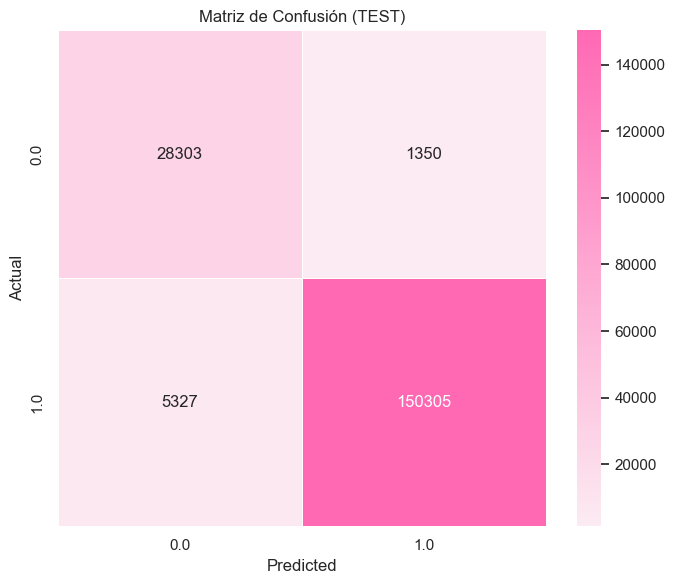

Matriz de confusión (raw):
[[ 28303   1350]
 [  5327 150305]]


In [10]:
# =========================
# Matriz de Confusión
# =========================

cm = confusion_matrix(y_true, y_pred)

# Inferimos orden de etiquetas para etiquetar el heatmap
labels_sorted = np.unique(y_true)

plt.figure(figsize=(7, 6))

# Creamos un degradado personalizado desde un rosado
cmap_rosa = LinearSegmentedColormap.from_list("custom_pink", ["#fcebf2", "hotpink"])

# Paleta corporativa sugerida: tonos morados/rosas
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cmap_rosa,
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
)

plt.title("Matriz de Confusión (TEST)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Matriz de confusión (raw):")
print(cm)


### Interpretación de la Matriz de Confusión

La matriz de confusión permite analizar con mayor detalle los aciertos y errores cometidos por el modelo en el conjunto de prueba.

#### Resultados obtenidos

- Verdaderos Negativos (TN): 28.303
- Falsos Positivos (FP): 1.350
- Falsos Negativos (FN): 5.327
- Verdaderos Positivos (TP): 150.305

#### Análisis

El modelo clasifica correctamente la gran mayoría de las observaciones pertenecientes a ambas clases.

Se observa una cantidad muy baja de **falsos positivos (1.350)**, lo que significa que rara vez predice que un producto será recomendado cuando en realidad no lo es.

Asimismo, los **verdaderos positivos (150.305)** representan la mayor parte de las observaciones positivas, confirmando la elevada capacidad del modelo para detectar productos efectivamente recomendados.

Los **falsos negativos (5.327)** corresponden a productos que sí fueron recomendados por los usuarios pero que el modelo clasificó como no recomendados. Aunque este error existe, su magnitud es reducida en comparación con el número total de recomendaciones correctas.

#### Conclusión

La matriz de confusión confirma los resultados observados en las métricas anteriores. El modelo presenta una alta capacidad de discriminación entre productos recomendados y no recomendados, manteniendo una baja proporción de errores y una elevada cantidad de clasificaciones correctas.

Estos resultados respaldan la utilización del modelo como herramienta predictiva para estimar la probabilidad de recomendación de productos cosméticos.

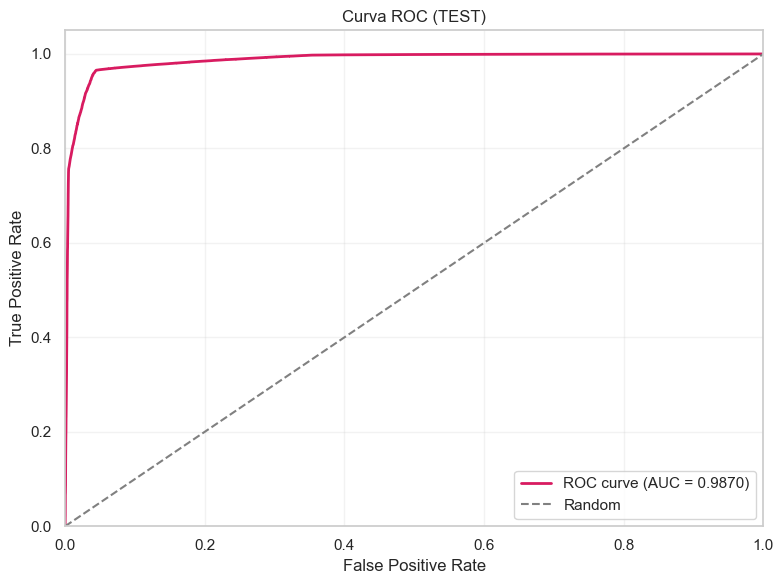

AUC ROC (TEST): 0.986957


In [11]:
# =========================
# Curva ROC y AUC
# =========================

# ROC: necesitaremos fpr, tpr y umbral implícito (derivado internamente)
fpr, tpr, thresholds = roc_curve(y_true, y_score_for_roc)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#d81b60", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (TEST)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"AUC ROC (TEST): {roc_auc_value:.6f}")


### Interpretación de la Curva ROC y el AUC

La curva ROC (*Receiver Operating Characteristic*) permite evaluar la capacidad de discriminación del modelo a través de distintos umbrales de clasificación.

A diferencia de métricas como Accuracy, Precision o Recall, que dependen de un umbral específico de clasificación, la curva ROC evalúa el comportamiento del modelo considerando todos los umbrales posibles.

#### Área Bajo la Curva (AUC)

El indicador más importante derivado de la ROC es el **AUC (Area Under the Curve)**.

Su interpretación general es:

- **AUC = 0.50:** rendimiento equivalente al azar.
- **0.50 < AUC < 0.70:** capacidad discriminativa baja.
- **0.70 ≤ AUC < 0.90:** buena capacidad discriminativa.
- **AUC ≥ 0.90:** excelente capacidad discriminativa.
- **AUC = 1.00:** clasificación perfecta.

#### Resultados obtenidos

El modelo alcanzó un valor de:

\[
AUC = 0.986957
\]

Este resultado indica una capacidad de discriminación extremadamente alta entre las clases **is_recommended** y **no_recommended**.

En términos prácticos, significa que existe aproximadamente un **98,70% de probabilidad** de que el modelo asigne una puntuación más alta a un producto realmente recomendado que a uno no recomendado seleccionado aleatoriamente.

#### Interpretación para el negocio

El elevado valor de AUC confirma que el modelo no solo clasifica correctamente utilizando el umbral por defecto, sino que además genera probabilidades altamente informativas.

Esto resulta especialmente valioso en sistemas de recomendación, donde podrían definirse distintos umbrales de decisión dependiendo de los objetivos del negocio o del costo asociado a falsos positivos y falsos negativos.

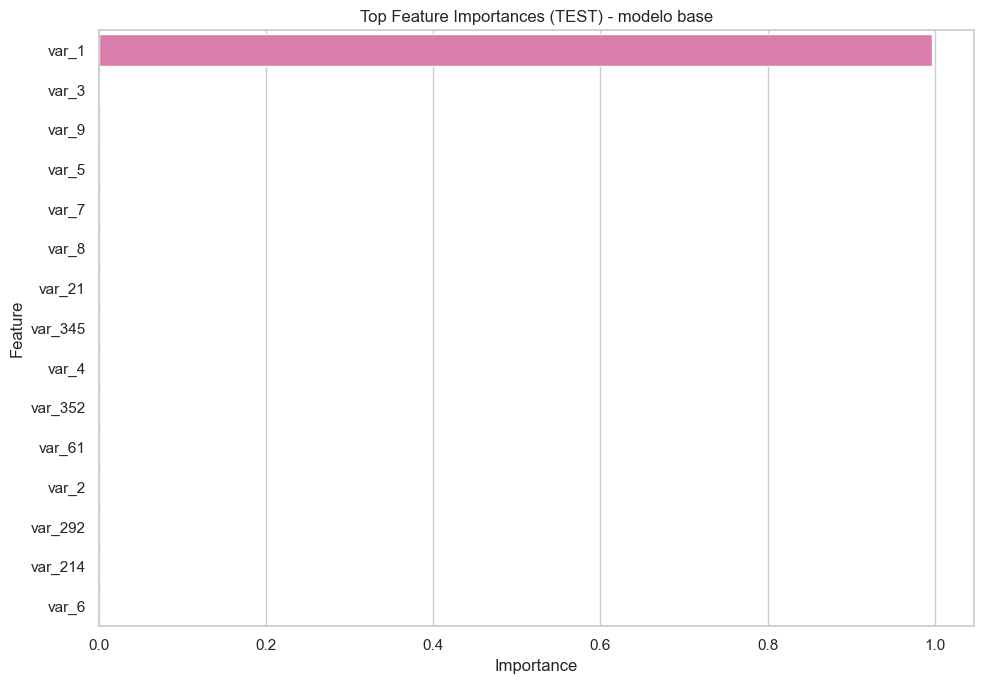

Top features:
- var_1: 0.99706061
- var_3: 0.00068756
- var_9: 0.00051515
- var_5: 0.00038975
- var_7: 0.00019991
- var_8: 0.00015581
- var_21: 0.00011822
- var_345: 0.00009162
- var_4: 0.00008649
- var_352: 0.00006397
- var_61: 0.00006145
- var_2: 0.00006106
- var_292: 0.00003674
- var_214: 0.00003662
- var_6: 0.00003381


In [12]:
# =========================
# Importancia de Variables (Feature Importance)
# =========================

# Muchos modelos de boosting y random forest exponen feature_importances_.
# Si no existe, se informa de forma controlada.

feature_importances = getattr(best_model, "feature_importances_", None)

if feature_importances is None:
    print("El modelo no expone feature_importances_.")
    print("Se omite el gráfico de importancia de variables.")
else:
    feature_importances = np.asarray(feature_importances)

    # Intento de obtener nombres de columnas si el pipeline los conserva.
    # Dado que se asume que X_test puede no tener nombres, usamos fallback por índice.
    feature_names = None

    # Caso típico: si best_model es un pipeline, podría contener un preprocesador.
    # Sin embargo, el artefacto best_model.pkl podría ser un estimador ya ajustado.
    # Aquí intentamos heurísticas seguras.
    if hasattr(best_model, "named_steps"):
        # Si es Pipeline, buscaremos preprocesador y nombres
        try:
            # common transformers: preprocessor / ColumnTransformer
            preprocessor = None
            for _, step in best_model.named_steps.items():
                # heurística: ColumnTransformer suele tener get_feature_names_out
                if hasattr(step, "get_feature_names_out"):
                    preprocessor = step
                    break
            if preprocessor is not None:
                feature_names = preprocessor.get_feature_names_out()
        except Exception:
            feature_names = None

    if feature_names is None:
        feature_names = [f"var_{i}" for i in range(feature_importances.shape[0])]

    # Validación de longitudes
    if len(feature_names) != len(feature_importances):
        feature_names = [f"var_{i}" for i in range(len(feature_importances))]

    # Top 15
    top_k = 15
    top_idx = np.argsort(feature_importances)[::-1][:top_k]
    top_importances = feature_importances[top_idx]
    top_features = np.array(feature_names)[top_idx]

    plt.figure(figsize=(10, 7))
    sns.barplot(x=top_importances, y=top_features, color="#E76FAD")
    plt.title("Top Feature Importances (TEST) - modelo base")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("Top features:")
    for f, imp in zip(top_features, top_importances):
        print(f"- {f}: {imp:.8f}")


### Interpretación de la Importancia de Variables

El modelo seleccionado permite estimar la importancia relativa de las variables utilizadas durante el proceso de clasificación mediante el atributo `feature_importances_`.

Este análisis tiene como objetivo comprender qué variables influyen con mayor intensidad en las decisiones del modelo y aportar una capa adicional de interpretabilidad al proceso predictivo.

#### Resultados obtenidos

El gráfico de importancia muestra que una variable domina ampliamente el proceso de decisión:

- `var_1`: importancia ≈ 99,71%
- Resto de variables: importancia individual inferior al 0,1%

Esto indica que el modelo depende principalmente de una única característica para realizar la clasificación, mientras que las demás variables aportan una contribución mucho menor.

En este proyecto los datos fueron previamente transformados mediante un pipeline de preprocesamiento que incluye codificación de variables categóricas y otras transformaciones.

Como consecuencia:

- Las variables originales pueden haberse expandido en múltiples columnas.
- Los nombres originales de las variables no se conservaron dentro del artefacto final del modelo.
- Por este motivo, las importancias aparecen identificadas mediante nombres genéricos (`var_0`, `var_1`, `var_2`, etc.).

#### Posible explicación

La elevada importancia de `var_1` podría indicar que dicha variable contiene una gran cantidad de información predictiva respecto a la recomendación del producto.

Sin embargo, también podría sugerir:

- Presencia de variables altamente correlacionadas.
- Variables derivadas con gran poder predictivo.
- Posible redundancia entre múltiples características del dataset.

Por esta razón, sería recomendable en futuras iteraciones recuperar los nombres originales de las variables transformadas para identificar exactamente qué atributo representa `var_1`.

#### Limitaciones

La importancia de variables no debe interpretarse como evidencia de causalidad.

Una alta importancia indica que la variable fue útil para el modelo durante el entrenamiento, pero no demuestra que dicha variable sea la causa directa del comportamiento observado.

Además, estas métricas pueden verse afectadas por:

- Correlación entre variables.
- Colinealidad.
- Transformaciones realizadas durante el preprocesamiento.

9. Discusión sobre Generalización (Test vs Validación Cruzada)
Los resultados en test deben compararse mentalmente con los obtenidos anteriormente en validación cruzada (CV). En un escenario ideal, el desempeño observado en CV (promedio) es consistente con el rendimiento en test.

Evidencia esperada si el modelo generaliza bien
Si el modelo:

aprendió patrones verdaderos y no ruido
no sufrió sobreajuste significativo
entonces deberíamos observar en test:

métricas (F1/ROC-AUC) cercanas a las medias de CV
estabilidad razonable en la matriz de confusión (no aparición masiva de errores nuevos)
una ROC-AUC alta que refleje separación robusta entre clases
Evidencia típica de sobreajuste (overfitting)
El sobreajuste se manifiesta cuando:

CV reporta rendimiento alto, pero test cae de forma marcada
la matriz de confusión revela que en test el modelo “se rompe” particularmente en la clase minoritaria
precision/recall se desbalancean fuertemente
ROC-AUC disminuye notablemente respecto a la intuición de CV
En este notebook, el test funciona como “prueba de realidad”: no interviene en el entrenamiento, y por tanto cualquier divergencia fuerte con CV constituye un indicador de posible overfitting.

Nota metodológica (aseguramiento del rigor)
El cumplimiento de la restricción crítica (no usar entrenamiento para evaluación) es una condición necesaria para la validez externa del análisis. Esta separación evita:

leakage
sobreoptimización indirecta
sobreestimación del rendimiento

## Conclusiones Finales

En este notebook se realizó la evaluación final del modelo seleccionado utilizando exclusivamente el conjunto de prueba, garantizando que las métricas obtenidas representen una estimación realista de su capacidad de generalización sobre datos no observados previamente.

Los resultados obtenidos muestran un desempeño altamente satisfactorio:

- Accuracy: **96,40%**
- Precision: **99,11%**
- Recall: **96,58%**
- F1-score: **97,83%**
- ROC-AUC: **98,70%**

El análisis de estas métricas evidencia que el modelo posee una excelente capacidad para distinguir entre productos recomendados y no recomendados, manteniendo simultáneamente una alta precisión y una elevada cobertura de casos positivos.

La matriz de confusión confirmó que la cantidad de errores es reducida en comparación con el volumen total de observaciones evaluadas. Además, el modelo mostró un comportamiento estable tanto para la clase mayoritaria (*is_recommended*) como para la clase minoritaria (*no_recommended*), aunque esta última presenta métricas ligeramente inferiores debido al desbalance existente en los datos.

Por otra parte, la curva ROC y el valor de AUC obtenido demuestran una capacidad discriminativa sobresaliente, indicando que el modelo es capaz de separar correctamente ambas clases incluso bajo distintos umbrales de decisión.

Respecto a la interpretabilidad, el análisis de importancia de variables reveló que una pequeña cantidad de características concentra gran parte del poder predictivo del modelo, destacando especialmente una variable dominante dentro del conjunto transformado.

#### Posibles mejoras futuras

Aunque los resultados son muy positivos, existen oportunidades de mejora para futuras versiones del proyecto:

- Recuperar los nombres originales de las variables transformadas para mejorar la interpretabilidad.
- Realizar calibración de probabilidades para optimizar la selección de umbrales de decisión.
- Analizar el comportamiento del modelo por segmentos específicos de productos o usuarios.
- Incorporar técnicas avanzadas de explicabilidad como SHAP o Permutation Importance.
- Experimentar con modelos adicionales y estrategias de balanceo de clases.

### Conclusión General

El proceso completo de preparación de datos, entrenamiento, selección de modelos, optimización de hiperparámetros y evaluación final permitió construir un clasificador con un alto nivel de desempeño predictivo. Los resultados obtenidos demuestran que las características disponibles contienen información relevante para anticipar si un producto será recomendado por los usuarios, cumpliendo satisfactoriamente los objetivos planteados para este proyecto.

C:\Users\maria\AppData\Local\Temp\ipykernel_34180\2686205039.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


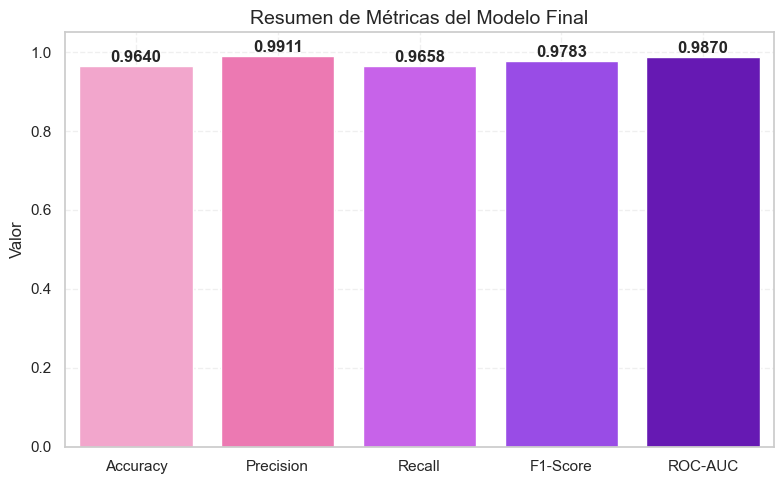


================ RESUMEN FINAL DE EVALUACIÓN ================

Accuracy  : 0.963964
Precision : 0.991098
Recall    : 0.965772
F1-Score  : 0.978271
ROC-AUC   : 0.986957



In [13]:
# =====================================================
# Resumen final de métricas del modelo
# =====================================================

metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc_value
    ]
})

# -----------------------------
# Visualización
# -----------------------------

plt.figure(figsize=(8, 5))

# Definimos una lista de 5 colores que van de rosa claro a morado oscuro
colores_rosa_morado = ["#FF99CC", "#FF66B2", "#D24DFF", "#9933FF", "#6600CC"]

sns.barplot(
    data=metrics_df,
    x="Métrica",
    y="Valor",
    palette=colores_rosa_morado
)

plt.ylim(0, 1.05)

plt.title(
    "Resumen de Métricas del Modelo Final",
    fontsize=14
)

plt.ylabel("Valor")
plt.xlabel("")

# Mostrar valor encima de cada barra
for i, valor in enumerate(metrics_df["Valor"]):
    plt.text(
        i,
        valor + 0.01,
        f"{valor:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# -----------------------------
# Resumen numérico
# -----------------------------

print("\n================ RESUMEN FINAL DE EVALUACIÓN ================\n")

for _, row in metrics_df.iterrows():
    print(f"{row['Métrica']:10s}: {row['Valor']:.6f}")

print("\n============================================================")